<a href="https://colab.research.google.com/github/felipebatalini/AIHC5020/blob/main/final_exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem 1: Summarizing Data Types in Python

In [1]:
import pandas as pd

# Define the summary data for primitive and collection types
data = [
    {
        "name": "Integer",
        "python_symbol": "int",
        "example": str(25),
        "falsy_value": str(0),
        "usage": "Represents whole numbers"
    },
    {
        "name": "Floating Point",
        "python_symbol": "float",
        "example": str(3.14),
        "falsy_value": str(0.0),
        "usage": "Represents real numbers with fractional parts"
    },
    {
        "name": "Boolean",
        "python_symbol": "bool",
        "example": str(True),
        "falsy_value": str(False),
        "usage": "Represents truth values (True or False)"
    },
    {
        "name": "String",
        "python_symbol": "str",
        "example": str("hello"),
        "falsy_value": str(""),
        "usage": "Represents sequences of characters"
    },
    {
        "name": "Bytes",
        "python_symbol": "bytes",
        "example": str(b"data"),
        "falsy_value": str(b""),
        "usage": "Represents immutable sequences of raw binary bytes"
    },
    {
        "name": "NoneType",
        "python_symbol": "NoneType",
        "example": str(None),
        "falsy_value": str(None),
        "usage": "Represents the absence of a value"
    },
    {
        "name": "List",
        "python_symbol": "list",
        "example": str([1, 2, 3]),
        "falsy_value": str([]),
        "usage": "Represents ordered, mutable sequences of elements"
    },
    {
        "name": "Tuple",
        "python_symbol": "tuple",
        "example": str((1, 2, 3)),
        "falsy_value": str(()),
        "usage": "Represents ordered, immutable sequences of elements"
    },
    {
        "name": "Dictionary",
        "python_symbol": "dict",
        "example": str({"key": "value"}),
        "falsy_value": str({}),
        "usage": "Represents key-value pairs"
    }
]

df_types = pd.DataFrame(data)
df_types

,name,python_symbol,example,falsy_value,usage
0,Integer,int,25,0,Represents whole numbers
1,Floating Point,float,3.14,0.0,Represents real numbers with fractional parts
2,Boolean,bool,True,False,Represents truth values (True or False)
3,String,str,hello,,Represents sequences of characters
4,Bytes,bytes,b'data',b'',Represents immutable sequences of raw binary b...
5,NoneType,NoneType,None,None,Represents the absence of a value
6,List,list,"[1, 2, 3]",[],"Represents ordered, mutable sequences of elements"
7,Tuple,tuple,"(1, 2, 3)",(),"Represents ordered, immutable sequences of ele..."
8,Dictionary,dict,{'key': 'value'},{},Represents key-value pairs


Problem 2: Chat Log Data

In [17]:
from google.cloud import storage

client = storage.Client.create_anonymous_client()
bucket = client.bucket("cloud-samples-data")

# Print all blob names matching the sample-chat-logs prefix
blobs = list(bucket.list_blobs(prefix="ccai/sample-chat-logs"))
for b in blobs:
    print(b.name)

ccai/sample-chat-logs/chat_0.json
ccai/sample-chat-logs/chat_1.json
ccai/sample-chat-logs/chat_10.json
ccai/sample-chat-logs/chat_100.json
ccai/sample-chat-logs/chat_1000.json
ccai/sample-chat-logs/chat_1001.json
ccai/sample-chat-logs/chat_1002.json
ccai/sample-chat-logs/chat_1003.json
ccai/sample-chat-logs/chat_1004.json
ccai/sample-chat-logs/chat_1005.json
ccai/sample-chat-logs/chat_1006.json
ccai/sample-chat-logs/chat_1007.json
ccai/sample-chat-logs/chat_1008.json
ccai/sample-chat-logs/chat_1009.json
ccai/sample-chat-logs/chat_101.json
ccai/sample-chat-logs/chat_1010.json
ccai/sample-chat-logs/chat_1011.json
ccai/sample-chat-logs/chat_1012.json
ccai/sample-chat-logs/chat_1013.json
ccai/sample-chat-logs/chat_1014.json
ccai/sample-chat-logs/chat_1015.json
ccai/sample-chat-logs/chat_1016.json
ccai/sample-chat-logs/chat_1017.json
ccai/sample-chat-logs/chat_1018.json
ccai/sample-chat-logs/chat_1019.json
ccai/sample-chat-logs/chat_102.json
ccai/sample-chat-logs/chat_1020.json
ccai/sample-

In [23]:
import json
from datetime import datetime, timezone
from google.cloud import storage
import pandas as pd

def process_chat_log(chat_id: int) -> pd.DataFrame:
    client = storage.Client.create_anonymous_client()
    bucket = client.bucket("cloud-samples-data")

    # We verified the exact path via your list_blobs diagnostic
    blob = bucket.blob(f"ccai/sample-chat-logs/chat_{chat_id}.json")

    if not blob.exists():
        print(f"File not found for ID: {chat_id}")
        return None

    data = json.loads(blob.download_as_text())
    rows = []

    # Handle both top-level list arrays and wrapped dictionary objects
    if isinstance(data, list):
        entries = data
    elif isinstance(data, dict):
        entries = data.get("entries", data.get("messages", [data]))
    else:
        entries = []

    for entry in entries:
        if not isinstance(entry, dict):
            continue

        # 1. Flexible Timestamp Extraction
        ts = (
            entry.get("start_timestamp_usec") or
            entry.get("send_time") or
            entry.get("timestamp") or
            entry.get("time") or
            entry.get("createTime")
        )

        if ts:
            try:
                ts_float = float(ts)
                # Convert microseconds to seconds if necessary
                if ts_float > 1e12:
                    ts_float = ts_float / 1000000.0
                dt = datetime.fromtimestamp(ts_float, tz=timezone.utc)
                formatted_time = dt.strftime("%Y-%m-%d %H:%M:%S")
            except (ValueError, TypeError):
                formatted_time = str(ts) # Fallback if it's already a formatted string
        else:
            formatted_time = None

        # 2. Flexible Text & Sender Extraction

        # Pattern A: Flat Schema (Catches standard 'sender'/'author' and 'text'/'content')
        flat_text = entry.get("text") or entry.get("content") or entry.get("message")
        flat_sender = entry.get("sender") or entry.get("author") or entry.get("role")

        if flat_text is not None:
            rows.append({
                "timestamp": formatted_time,
                "sender": flat_sender if flat_sender else "UNKNOWN",
                "text": flat_text,
                "id": chat_id
            })
            continue

        # Pattern B: Nested CCAI User Turn (Dialogflow structure)
        if "annotated_user_turn" in entry:
            try:
                text_node = entry["annotated_user_turn"]["user_input"]["query_input"]["text"]
                user_text = text_node.get("text") if isinstance(text_node, dict) else text_node
                rows.append({
                    "timestamp": formatted_time,
                    "sender": "USER",
                    "text": user_text,
                    "id": chat_id
                })
            except KeyError:
                pass

        # Pattern C: Nested CCAI Agent Turn (Dialogflow structure)
        if "text_responses" in entry:
            for resp in entry.get("text_responses", {}).get("entries", []):
                if isinstance(resp, dict) and "text" in resp:
                    rows.append({
                        "timestamp": formatted_time,
                        "sender": "AGENT",
                        "text": resp["text"],
                        "id": chat_id
                    })

    return pd.DataFrame(rows)

# Test for ID 101
chat_df = process_chat_log(101)
chat_df

,timestamp,sender,text,id
0,2023-02-23 02:07:40,AGENT,"Hello, how can I assist you today?",101
1,2023-02-23 02:07:58,CUSTOMER,"Hi, I'm having an issue with my laptop",101
2,2023-02-23 02:08:16,AGENT,Sorry to hear. Can you tell me what the proble...,101
3,2023-02-23 02:08:34,CUSTOMER,The laptop is not connecting to the internet. ...,101
4,2023-02-23 02:08:52,AGENT,Can you give me more details about the problem...,101
5,2023-02-23 02:09:10,CUSTOMER,The problem with the laptop is still happening...,101
6,2023-02-23 02:09:28,AGENT,And what is the status shown in the settings o...,101
7,2023-02-23 02:09:46,CUSTOMER,Warning: No available storage. Your computer's...,101
8,2023-02-23 02:10:04,AGENT,Can you tell me your account number?,101
9,2023-02-23 02:10:22,CUSTOMER,"Sure, it's 407106565",101


Problem 3: Chest X-ray DICOM Manifest

In [24]:
# Install required dependency if not already present
!pip install -q pydicom

import os
import pandas as pd
import pydicom
from google.colab import drive

# Mount Google Drive safely without forcing re-mount if already mounted
drive_path = "/content/drive"
if not os.path.exists(os.path.join(drive_path, "MyDrive")):
    drive.mount(drive_path)

def create_dicom_manifest(folder_path: str) -> pd.DataFrame:
    """
    Parses a directory containing DICOM files and returns a summary DataFrame manifest
    describing DICOM series metadata.
    """
    series_dict = {}

    for root, _, files in os.walk(folder_path):
        for file in files:
            # Check for DICOM extension or files without extensions typical of DICOM
            if file.endswith(('.dcm', '.DICOM')) or '.' not in file:
                file_path = os.path.join(root, file)
                try:
                    # Read metadata without loading heavy pixel data into memory
                    ds = pydicom.dcmread(file_path, stop_before_pixels=True)
                    series_uid = getattr(ds, "SeriesInstanceUID", "Unknown")

                    if series_uid not in series_dict:
                        series_dict[series_uid] = {
                            "series_uid": series_uid,
                            "study_uid": getattr(ds, "StudyInstanceUID", "Unknown"),
                            "patient_id": getattr(ds, "PatientID", "Unknown"),
                            "study_date": getattr(ds, "StudyDate", "Unknown"),
                            "modality": getattr(ds, "Modality", "Unknown"),
                            "number_of_images": 1,
                            "series_directory": root
                        }
                    else:
                        series_dict[series_uid]["number_of_images"] += 1
                except Exception:
                    continue

    df_manifest = pd.DataFrame(list(series_dict.values()))
    return df_manifest

# Generate and display the first 5 rows of the DICOM manifest
dicom_dir = "/content/drive/MyDrive/AIHC5020/dicom/chest_xray"
manifest_df = create_dicom_manifest(dicom_dir)
manifest_df.head()

,series_uid,study_uid,patient_id,study_date,modality,number_of_images,series_directory
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.140111454550...,1.3.6.1.4.1.14519.5.2.1.6279.6001.213083367261...,LIDC-IDRI-0015,20000101,DX,1,/content/drive/MyDrive/AIHC5020/dicom/chest_xr...
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.541650212189...,1.3.6.1.4.1.14519.5.2.1.6279.6001.675114969651...,LIDC-IDRI-0023,20000101,DX,2,/content/drive/MyDrive/AIHC5020/dicom/chest_xr...
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.239368516910...,1.3.6.1.4.1.14519.5.2.1.6279.6001.333103030188...,LIDC-IDRI-0012,20000101,DX,2,/content/drive/MyDrive/AIHC5020/dicom/chest_xr...
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.151706669339...,1.3.6.1.4.1.14519.5.2.1.6279.6001.294023360260...,LIDC-IDRI-0024,20000101,DX,2,/content/drive/MyDrive/AIHC5020/dicom/chest_xr...
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.334422875695...,1.3.6.1.4.1.14519.5.2.1.6279.6001.302822025885...,LIDC-IDRI-0040,20000101,DX,2,/content/drive/MyDrive/AIHC5020/dicom/chest_xr...


Problem 4: Visualizing Chest X-Rays

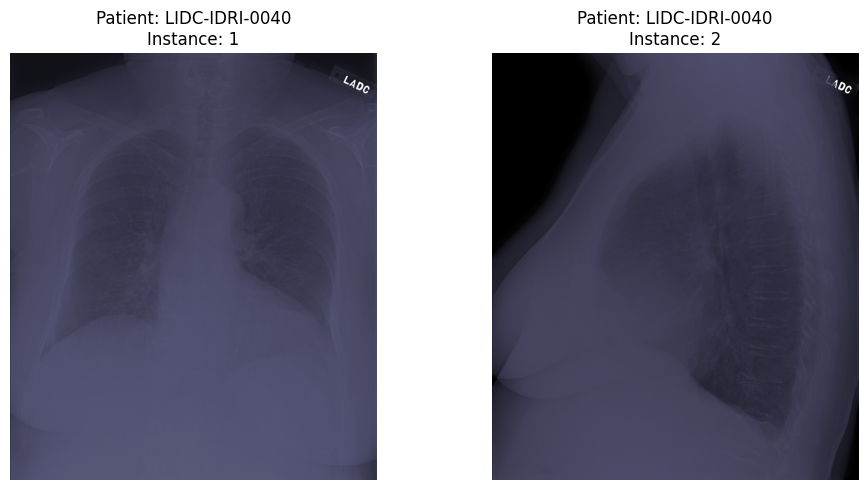

In [25]:
import os
import glob
import matplotlib.pyplot as plt
import pydicom

def visualize_patient_xrays(patient_id: str, manifest_df: pd.DataFrame):
    """
    Visualizes all DICOM instances associated with a specified patient ID.
    """
    patient_rows = manifest_df[manifest_df['patient_id'] == patient_id]

    if patient_rows.empty:
        print(f"Patient ID '{patient_id}' not found in manifest.")
        return None

    dcm_files = []
    for _, row in patient_rows.iterrows():
        series_dir = row['series_directory']
        for root, _, files in os.walk(series_dir):
            for f in files:
                full_path = os.path.join(root, f)
                try:
                    ds = pydicom.dcmread(full_path)
                    if getattr(ds, 'PatientID', None) == patient_id:
                        dcm_files.append((full_path, ds))
                except Exception:
                    continue

    if not dcm_files:
        print(f"No readable DICOM instances located for patient '{patient_id}'.")
        return None

    num_images = len(dcm_files)
    fig, axes = plt.subplots(1, num_images, figsize=(5 * num_images, 5), squeeze=False)

    for idx, (path, ds) in enumerate(dcm_files):
        ax = axes[0, idx]
        ax.imshow(ds.pixel_array, cmap=plt.cm.bone)
        instance_num = getattr(ds, 'InstanceNumber', idx + 1)
        ax.set_title(f"Patient: {patient_id}\nInstance: {instance_num}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Visualize for patient LIDC-IDRI-0040
visualize_patient_xrays("LIDC-IDRI-0040", manifest_df)